# Cox Model

- 1 Log-rank test $\rightarrow$ Non-parametric comparison of survival curves
    - You have two or more groups (e.g., Men vs. Women) and want to know: "Are these survival curves significantly different, or is this gap just random noise?"How it works: It is non-parametric. At every single distinct time point where a death occurs, it calculates the expected number of deaths in each group if the survival rates were completely identical, and compares it to the observed deaths. It aggregates these across the whole timeline to generate a $p$-value.
- 2: Cox model $\rightarrow$ Parametric regression on hazard ratios
    - The log-rank test only lets you compare distinct groups (like Sex). But what if you want to evaluate a continuous variable like Gross Tumor Volume (gtv), or look at all predictors simultaneously? You need a regression model.How it works: It evaluates the Hazard Ratio (HR). If a covariate has an HR of 1.5, it means a patient with that characteristic is $50\%$ more likely to experience the event (death) at any given moment compared to a baseline patient. It is "parametric" regarding the covariates because it assumes their effect on risk is a fixed, constant multiplier over time.
- 3: Cox score test $\rightarrow$ Log-rank test in regression form
    - To prove that the Log-Rank test and the Cox Regression model are fundamentally parts of the same mathematical family.How it works: If you run a Cox regression model with only one binary covariate (e.g., Sex), and you test whether that covariate's coefficient is significantly different from zero using a mathematical check called the Score Test, the math works out to be exactly identical to running a traditional Log-Rank test. It's the mathematical bridge showing that a group comparison is just a simplified version of a regression.

| Concept       | Meaning                                                       |
| ------------- | ------------------------------------------------------------- |
| Kaplan–Meier  | estimates survival probabilities over time                    |
| Log-rank test | compares observed vs expected deaths                          |
| Cox model     | assigns risk scores so observed death ordering is most likely |


In [2]:
# --- 1. CORE DATA & VIZ ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
%matplotlib inline

# --- 2. STATSMODELS (Statistical Inference & Formulas) ---
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm
from statsmodels.nonparametric.smoothers_lowess import lowess

# --- 3. SKLEARN: PREPROCESSING & DATA PIPELINES ---
from sklearn.model_selection import (
    train_test_split, LeaveOneOut, KFold, 
    cross_val_score, GridSearchCV, RandomizedSearchCV)

from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, PolynomialFeatures, OneHotEncoder)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# --- 4. SKLEARN: LINEAR MODELS (Chapter 3, 4, & 6) ---
from sklearn.linear_model import (
    LinearRegression, LogisticRegression, 
    Ridge, Lasso, ElasticNet, RidgeCV, LassoCV)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# --- 5. SKLEARN: MODEL SELECTION & DIMENSIONALITY REDUCTION (Chapter 6) ---
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression

# --- 6. SKLEARN: TREE-BASED MODELS & ENSEMBLES (Chapter 8) ---
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    GradientBoostingRegressor, GradientBoostingClassifier, HistGradientBoostingClassifier,
    BaggingRegressor, BaggingClassifier, AdaBoostRegressor)

# --- 7. SKLEARN: SUPPORT VECTOR MACHINES (Chapter 9) ---
from sklearn.svm import SVC, SVR, LinearSVC
from sklearn.inspection import DecisionBoundaryDisplay

# --- 8. SKLEARN: NEAREST NEIGHBORS & CLUSTERING (Chapter 4 & 12) ---
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.cluster import KMeans, AgglomerativeClustering

# --- 9. SKLEARN: EVALUATION METRICS ---
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error, precision_score, recall_score, 
    f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, 
    roc_curve, auc, roc_auc_score,RocCurveDisplay, silhouette_score)

# --- 10. UTILS & RESAMPLING ---
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')
from patsy import (dmatrix, bs)

# --- 11. SURVIVAL ANALYSIS (Industry Standard) ---
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

## Cox Proportional Hazards Model (Brain Cancer Data)

In [10]:
df = pd.read_csv("BrainCancer.csv")
df

,sex,diagnosis,loc,ki,gtv,stereo,status,time
0,Female,Meningioma,Infratentorial,90,6.11,SRS,0,57.64
1,Male,HG glioma,Supratentorial,90,19.35,SRT,1,8.98
2,Female,Meningioma,Infratentorial,70,7.95,SRS,0,26.46
3,Female,LG glioma,Supratentorial,80,7.61,SRT,1,47.80
4,Male,HG glioma,Supratentorial,90,5.06,SRT,1,6.30
...,...,...,...,...,...,...,...,...
83,Male,HG glioma,Supratentorial,80,0.16,SRT,1,20.69
84,Male,HG glioma,Supratentorial,80,19.81,SRT,1,6.39
85,Male,Meningioma,Supratentorial,90,2.50,SRT,0,32.82
86,Male,Meningioma,Supratentorial,90,2.02,SRS,0,42.07


In [11]:
# encode categorical variables
df_dummy = pd.get_dummies(df, columns=["sex", "diagnosis", "loc", "stereo"], drop_first=True)

df_dummy.head()

,ki,gtv,status,time,sex_Male,diagnosis_LG glioma,diagnosis_Meningioma,diagnosis_Other,loc_Supratentorial,stereo_SRT
0,90,6.11,0,57.64,False,False,True,False,False,False
1,90,19.35,1,8.98,True,False,False,False,True,True
2,70,7.95,0,26.46,False,False,True,False,False,False
3,80,7.61,1,47.80,False,True,False,False,True,True
4,90,5.06,1,6.30,True,False,False,False,True,True


In [12]:
cph = CoxPHFitter()
cph.fit(df_dummy, duration_col="time", event_col="status")

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 88 total observations, 53 right-censored observations>
             duration col = 'time'
                event col = 'status'
      baseline estimation = breslow
   number of observations = 88
number of events observed = 35
   partial log-likelihood = -118.41
         time fit was run = 2026-05-16 10:44:24 UTC

---
                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                             
ki                   -0.06      0.94      0.02           -0.09           -0.02                0.91                0.98
gtv                   0.04      1.04      0.02           -0.01            0.08                0.99                1.08
sex_Male              0.10      1.10      0.36           -0.61            0.80                0.54                2.24
diagnosis_LG glioma  -1.09      0.34      0.57           -2.22            0.03                0.11                1.03
diagnosis_Meningioma -2.08      0.12      0.45           -2.97           -1.19                0.05                0.30
diagnosis_Other      -1.24      0.29      0.63           -2.46           -0.01                0.09                0.99
loc_Supratentorial    0.38      1.46      0.70           -0.99            1.74                0.37                5.72
stereo_SRT            0.14      1.15      0.60           -1.03            1.31                0.36                3.71

                      cmp to     z      p  -log2(p)
covariate                                          
ki                      0.00 -3.16 <0.005      9.32
gtv                     0.00  1.59   0.11      3.17
sex_Male                0.00  0.27   0.79      0.35
diagnosis_LG glioma     0.00 -1.90   0.06      4.13
diagnosis_Meningioma    0.00 -4.59 <0.005     17.78
diagnosis_Other         0.00 -1.97   0.05      4.37
loc_Supratentorial      0.00  0.54   0.59      0.76
stereo_SRT              0.00  0.23   0.82      0.29
---
Concordance = 0.79
Partial AIC = 252.82
log-likelihood ratio test = 39.47 on 8 df
-log2(p) of ll-ratio test = 17.93

### 1. Model Overview

We fit a Cox proportional hazards model with:

- **Number of observations:** 88  
- **Number of events:** 35  
- **Baseline hazard estimation:** Breslow method  

The model estimates how clinical and demographic covariates affect the **instantaneous hazard of death**.

---

### 2. Global Model Fit

#### Likelihood ratio test

$$
\chi^2(8) = 39.47, \quad p < 0.001
$$

This indicates:

> The covariates jointly provide strong explanatory power for survival.

#### Concordance index

- **Concordance = 0.79**

Interpretation:

> In 79% of randomly chosen pairs, the model correctly orders survival times.

This indicates **strong predictive discrimination**.

---

### 3. Key Significant Predictors

#### (A) Karnofsky Index (ki)

| Quantity | Value |
|---|---|
| Coefficient | -0.06 |
| Hazard Ratio | 0.94 |
| p-value | < 0.005 |

Interpretation:

$$
HR = e^{-0.06} \approx 0.94
$$

> Each one-unit increase in Karnofsky index is associated with a **6% reduction in hazard**, holding all other variables fixed.

This is a **strong and statistically significant protective effect**.

#### (B) Tumor Type (Diagnosis)

##### LG glioma
- HR = 0.34, p ≈ 0.06 (borderline)

##### Meningioma
- HR = 0.12, p < 0.005 (**strong effect**)

##### Other
- HR = 0.29, p ≈ 0.05 (marginal)

Interpretation:

> Compared to the reference diagnosis group, all listed tumor types show **substantially lower hazard**, especially meningioma, which has the strongest protective association.

---

### 4. Non-significant Predictors

#### (A) Tumor volume (gtv)

- HR = 1.04
- p = 0.11

Interpretation:

> Slight positive association with hazard, but not statistically significant at the 5% level.


#### (B) Sex (Male)

- HR = 1.10
- p = 0.79

Interpretation:

> No evidence of a meaningful difference in survival between males and females after adjustment for other covariates.

#### (C) Location (Supratentorial)

- HR = 1.46
- p = 0.59

Interpretation:

> No statistically significant association with hazard.

#### (D) Stereotactic method (SRT)

- HR = 1.15
- p = 0.82

Interpretation:

> No evidence that treatment method (SRS vs SRT) affects survival in this adjusted model.

### 5. Overall Interpretation

The model suggests:

- Strong protective effect of **higher Karnofsky index**
- Strong differences across **tumor diagnosis categories**
- Weak or no evidence for effects of:
  - sex
  - tumor volume (marginal)
  - location
  - treatment type (SRS vs SRT)

> The Cox proportional hazards model indicates that functional status (Karnofsky index) and tumor diagnosis are the primary determinants of survival in this dataset. The model demonstrates strong predictive performance (concordance = 0.79) and a statistically significant overall fit (p < 0.001), while most demographic and treatment-related covariates do not show significant adjusted effects.

### Model Analysis: Cox-Predicted Survival Curves by Diagnosis

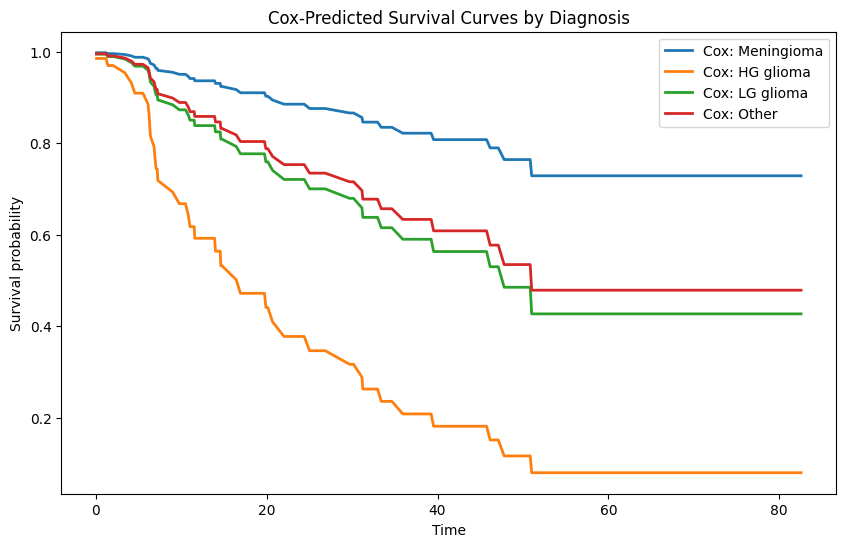

In [58]:
plt.figure(figsize=(10,6))

diagnoses = df["diagnosis"].str.strip().dropna().unique()

for g in diagnoses:
    profile = make_profile(g)
    
    surv = cph.predict_survival_function(profile)
    
    plt.plot(
        surv.index,
        surv.values.flatten(),
        linewidth=2,
        label=f"Cox: {g}"
    )

plt.title("Cox-Predicted Survival Curves by Diagnosis")
plt.xlabel("Time")
plt.ylabel("Survival probability")
plt.legend()
plt.show()

This note isolates the semi-parametric **Cox Proportional Hazards (CPH)** regression curves. It displays the model's predictions for each diagnostic cohort when continuous and demographic variables are adjusted and held constant at their dataset averages.

#### Underlying Mathematical Mechanics

The Cox Proportional Hazards model separates time-dependent risk from covariate-dependent risk using the following hazard function formula:

$$h(t \mid X) = h_0(t) \cdot e^{\beta_1 X_1 + \beta_2 X_2 + \dots + \beta_p X_p}$$

Where:
* $h_0(t)$ = The shared, non-parametric **baseline hazard function** that represents the underlying "clock" of risk over time.
* $e^{\beta X}$ = The parametric component representing the **Hazard Ratio (HR)** for a specific profile, which acts as a scaling multiplier.

##### Visual Properties of Semi-Parametric Curves:
* **The Shared Heartbeat:** Notice that every single curve takes a step downward at the exact same time points. They share a single, underlying, baseline risk clock $h_0(t)$ estimated from the entire dataset. 
* **Proportional Constraints:** Because the hazard ratio ($e^\beta$) is a constant multiplier that does not depend on time, the curves are mathematically restricted from crossing, converging, or showing group-specific timing features. They are locked into a fixed vertical hierarchy.

---

#### Model Interpretations & Covariate Control

In this specific visualization, all other model covariates are held constant at their mean values (e.g., Gross Tumor Volume `gtv` is set to the dataset average, Karnofsky index `ki` is set to average, and baseline sex is fixed). This allows us to isolate the pure predicted impact of **Diagnosis**:

* **Cox: Meningioma (Blue Curve):** Assigned the lowest hazard ratio multiplier by the model, shifting the shared baseline hazard to the highest position on the survival probability axis.
* **Cox: Other (Red Curve) & Cox: LG Glioma (Green Curve):** The model views these two diagnoses as carrying almost identical risk. Because their calculated $\beta$ coefficients are highly similar, their curves track nearly parallel and on top of each other throughout the timeline.
* **Cox: HG Glioma (Orange Curve):** Assigned a massive hazard ratio multiplier ($e^\beta \gg 1.0$). This dramatically scales up the baseline hazard, compressing its predicted survival curve downward toward the bottom of the axis.

---

> The Cox-Predicted plot represents an idealized, smoothed mathematical representation of risk based on the **Proportional Hazards Assumption**. By comparing this plot to the empirical Kaplan-Meier curves, an engineer or statistician can immediately spot model limitations. 
> For instance, while the raw data shows **LG Glioma** (Green) and **Other** (Red) separating wildly after Month 30, this plot shows them locked together forever. This over-smoothing occurs because a single Cox model forces all groups to conform to the average behavior of the dataset, trading group-specific nuances for general statistical power and multi-variable adjustment capabilities.

## Forest Plot

In [59]:
# extract summary table from lifelines model
summary = cph.summary.copy()

# keep only relevant columns
forest_df = summary[[
    "exp(coef)",
    "exp(coef) lower 95%",
    "exp(coef) upper 95%"
]]

forest_df = forest_df.sort_values("exp(coef)")

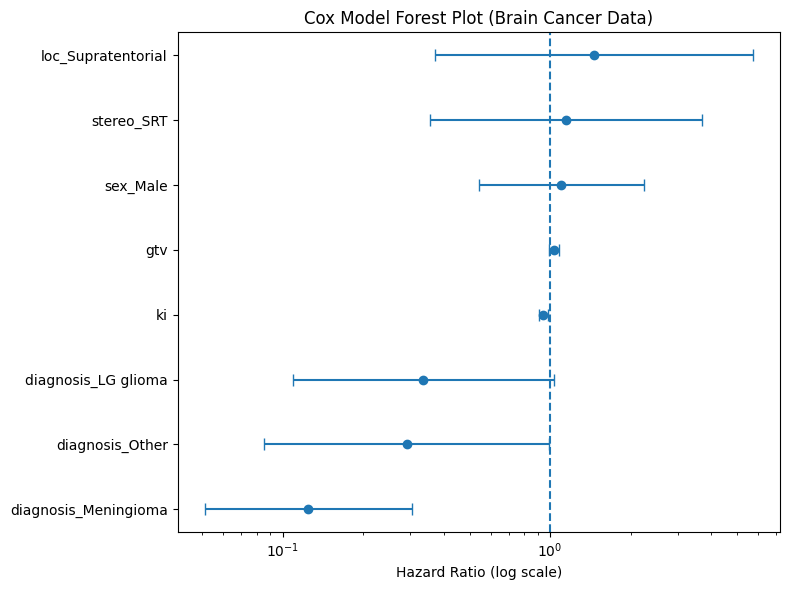

In [60]:
plt.figure(figsize=(8,6))

y_labels = forest_df.index
x = forest_df["exp(coef)"]
xerr_low = x - forest_df["exp(coef) lower 95%"]
xerr_high = forest_df["exp(coef) upper 95%"] - x

plt.errorbar(
    x,
    range(len(x)),
    xerr=[xerr_low, xerr_high],
    fmt='o',
    capsize=4
)

plt.yticks(range(len(x)), y_labels)
plt.axvline(1, linestyle="--")
plt.xscale("log")

plt.xlabel("Hazard Ratio (log scale)")
plt.title("Cox Model Forest Plot (Brain Cancer Data)")
plt.tight_layout()
plt.show()

A **Forest Plot** is the standard visual tool used in survival analysis to display the coefficients of a Cox Proportional Hazards regression model. Instead of looking at a raw text table of coefficients ($\beta$), this plot visualizes the estimated **Hazard Ratios (HR)** along with their **95% Confidence Intervals (CI)**.

To interpret any variable on this plot, you must look at three structural elements: **The Null Line, the Point Estimate, and the Error Bars.**

#### The Null Line ($\text{HR} = 1.0$)
The vertical dashed line at $1.0$ is the baseline of "no statistical difference."
* **$\text{HR} = 1.0$**: The covariate has absolutely zero effect on the risk of death.
* **$\text{HR} > 1.0$ (Right of the line)**: Increased risk. Exposure to this variable accelerates the event rate (shorter survival time).
* **$\text{HR} < 1.0$ (Left of the line)**: Decreased risk / Protective effect. This variable is associated with a lower risk of death (longer survival time).

#### 🔵 The Point Estimate (The Dot)
The solid blue dot represents the calculated Hazard Ratio ($e^{\beta}$) for that specific covariate. This is the most likely mathematical effect size given your data.

#### The Error Bars (Horizontal Whiskers)
The horizontal lines spanning out from each dot represent the **95% Confidence Interval**.
* **Statistical Significance Test:** If an error bar **crosses the vertical dashed line at 1.0**, the variable is **not statistically significant** ($p > 0.05$). It means the data cannot confidently rule out that the true effect size is actually zero.
* **If it does not cross 1.0**, the variable is a statistically significant predictor of survival ($p < 0.05$).

⚠️ **Note on the Scale:** The x-axis uses a **Logarithmic Scale** ($\log_{10}$ or natural log layout). This is mathematically necessary because Hazard Ratios are multiplicative geometric factors (e.g., an HR of $0.1$ is the exact inverse magnitude of an HR of $10.0$, so they deserve equal visual distance from $1.0$).

---
Let's break down the predictors from the `BrainCancer` model based on their visual placement:

#### Non-Significant Predictors (Crosses the Null Line)
* **`loc_Supratentorial`**: The error bars heavily overlap $1.0$. Tumor location (above vs. below the tentorium) does not show a statistically reliable impact on survival.
* **`stereo_SRT`**: This compares fractionated stereotactic radiotherapy (SRT) against the baseline method (SRS). Because the whiskers cross $1.0$, we cannot claim one stereotactic method performs better than the other in this sample.
* **`sex_Male`**: Being male sits slightly right of the line, but its confidence interval comfortably crosses $1.0$, meaning sex is not a significant driver of mortality here.

#### Significant Continuous Variables (Tight Whisker Profiles)
* **`gtv` (Gross Tumor Volume)**: The dot sits just to the *right* of $1.0$, and the error bars are incredibly tight and do not touch $1.0$. **Interpretation:** As tumor volume increases by 1 cubic centimeter, the risk of death significantly increases.
* **`ki` (Karnofsky Index)**: The dot sits just to the *left* of $1.0$ with a very narrow, significant interval. **Interpretation:** The Karnofsky Index measures a patient's functional status/well-being (higher score = better functional health). Because $\text{HR} < 1.0$, higher performance status acts as a significant protective factor, reducing the daily hazard rate.

#### Significant Categorical Predictors (The Diagnosis Reference Group)
Notice that **`diagnosis_HG glioma`** is completely missing from the y-axis. That is because it was omitted during dummy encoding (`drop_first=True`) and serves as the baseline **Reference Category** that all other diagnoses are being actively measured against.

Compared against High-Grade (HG) Gliomas:
* **`diagnosis_Meningioma`**: Sits far to the left ($\text{HR} \approx 0.12$). It is highly significant. Patients with Meningiomas have roughly an $88\%$ lower risk of death at any given time point compared to HG Glioma patients.
* **`diagnosis_Other` & `diagnosis_LG glioma`**: Both sit significantly to the left of $1.0$. This demonstrates that Low-Grade Gliomas and "Other" classifications carry a significantly lower hazard rate than aggressive High-Grade tumors.

---
> The forest plot reveals that **Tumor Diagnosis** is the most powerful predictor of survival, where all other diagnoses exhibit a massive, statistically significant protective survival effect when compared directly against the high-risk baseline of **High-Grade Gliomas**. Beyond tumor classification, a patient's baseline physical functionality (**`ki`**, protective) and physical tumor size (**`gtv`**, hazardous) are the only other significant drivers of survival variance. Demographic features (`sex`) and treatment methods (`stereo`) do not show significant impacts.

## Empirical Analysis: Kaplan-Meier Survival Curves by Diagnosis

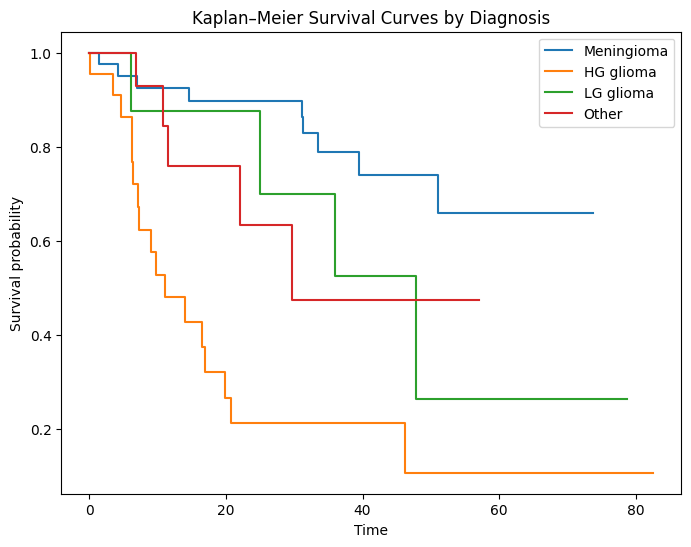

In [61]:
# safety cleanup (important even if data looks clean)
df["diagnosis"] = df["diagnosis"].str.strip()

kmf = KaplanMeierFitter()

plt.figure(figsize=(8,6))

for g in df["diagnosis"].dropna().unique():
    mask = df["diagnosis"] == g
    
    # safety check (THIS fixes your error)
    if mask.sum() == 0:
        continue
    
    kmf.fit(
        durations=df.loc[mask, "time"].astype(float),
        event_observed=df.loc[mask, "status"].astype(int),
        label=g
    )
    kmf.plot(ci_show=False)

plt.title("Kaplan–Meier Survival Curves by Diagnosis")
plt.xlabel("Time")
plt.ylabel("Survival probability")
plt.show()

This note analyzes the non-parametric **Kaplan-Meier (KM)** estimation of survival probabilities stratified purely by diagnostic category, reflecting the empirical, raw data profiles without covariate adjustments.

#### Underlying Mathematical Mechanics

The Kaplan-Meier estimator is a non-parametric statistic used to estimate the survival function $S(t)$ from lifetime data. It computes the probability of surviving past a distinct time point $t_i$ using the product of conditional probabilities:

$$S(t) = \prod_{t_i \le t} \left(1 - \frac{d_i}{n_i}\right)$$

Where:
* $d_i$ = The number of distinct events (deaths) occurring at time point $t_i$.
* $n_i$ = The total number of individuals surviving and remaining **at risk** just prior to time $t_i$.

##### Visual Properties of Non-Parametric Curves:
* **True Empirical Steps:** The lines change vertical level **only** at the precise timestamp a patient within that specific group passes away. If there are no deaths in a group over a long period, its curve remains completely flat.
* **Censoring Representation:** Patients who drop out or remain alive at the end of the study (censored data) do not cause a downward step; instead, they are dropped from the denominator ($n_i$) for subsequent risk calculations.
* **Independence:** Each diagnostic group's curve is calculated completely independently of the other groups.

---

#### Clinical Profiling of Diagnostic Groups

The raw empirical step functions illuminate distinct survival profiles and disease behaviors:

* **High-Grade (HG) Glioma (Orange Curve):** Demonstrates an aggressive, immediate risk profile. The curve drops steeply from the first month, with more than half of the cohort passing away before Month 15 ($S(t) < 0.5$). It stabilizes late near a $10\%$ survival floor.
* **Meningioma (Blue Curve):** Exhibits the most favorable clinical trajectory. Deaths are sparse and evenly distributed, with approximately $65\%$ of patients surviving past the 70-month mark. 
* **Low-Grade (LG) Glioma (Green Curve):** Displays a highly unique, delayed risk pattern. It tracks identically to the benign Meningioma cohort for the first 24 months, showing near $90\%$ survival. However, around Month 48, it suffers a severe, sudden drop down to the $26\%$ mark, suggesting a late-stage progression or recurrence threshold typical of low-grade tumors.
* **Other (Red Curve):** Shows intermediate, early volatility that flattens completely into a stable survival plateau of roughly $48\%$ after Month 30.

---

> The Kaplan-Meier plot is the fundamental starting point of survival analysis because it shows the untampered reality of the data. The stark structural differences between groups—such as the delayed cliff-drop in **LG Glioma** versus the constant step-downs of **HG Glioma**—serve as a vital warning sign that a standard regression model assuming a constant, proportional hazard ratio over time may fail to capture the true underlying epidemiology.

## Model Comparison: Kaplan-Meier vs. Cox Proportional Hazards

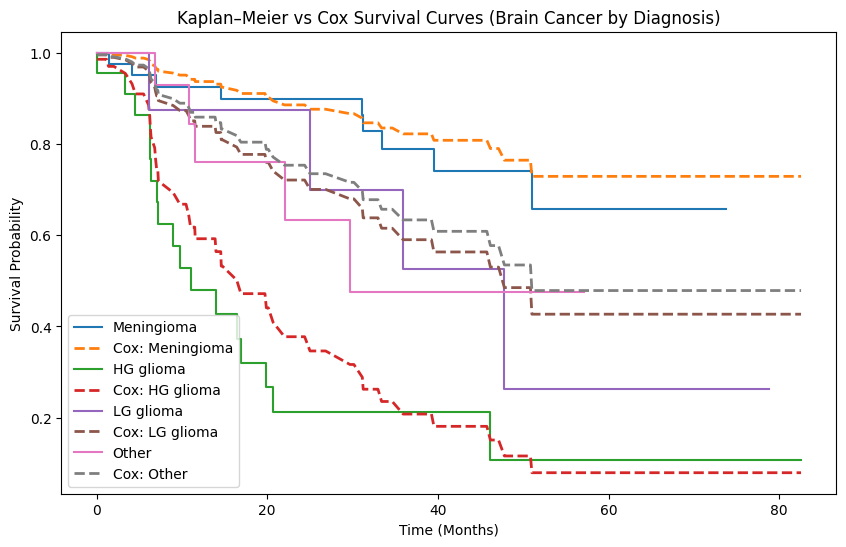

In [76]:
# --- 1. Clean Design Matrix Creation ---
# Keep it clean: directly map dummy variables and drop 'status' simultaneously
df_model = pd.get_dummies(
    df.rename(columns={"status": "event"}), 
    columns=["sex", "diagnosis", "loc", "stereo"], 
    drop_first=True
)

# --- 2. Fit Cox Model ---
cph = CoxPHFitter().fit(df_model, duration_col="time", event_col="event")

# --- 3. Plotting Setup ---
fig, ax = plt.subplots(figsize=(10, 6))
kmf = KaplanMeierFitter()
diagnoses = df["diagnosis"].dropna().unique()

# --- 4. Foolproof Curves Generation ---
for g in diagnoses:
    # A. Plot Kaplan-Meier (Solid lines)
    mask = df["diagnosis"] == g
    kmf.fit(df.loc[mask, "time"], df.loc[mask, "status"], label=g)
    kmf.plot_survival_function(ax=ax, ci_show=False)
    
    # B. Build Profile & Plot Cox (Dashed lines)
    profile = df_model.drop(columns=["time", "event"]).mean().to_frame().T
    
    # Set background baseline profile assumptions
    profile[["sex_Male", "stereo_SRT"]] = 0
    profile["loc_Supratentorial"] = 1
    
    # Reset all diagnosis dummies to 0, then switch ONLY the current group to 1
    diag_cols = [c for c in profile.columns if "diagnosis_" in c]
    profile[diag_cols] = 0
    if f"diagnosis_{g}" in profile.columns:
        profile[f"diagnosis_{g}"] = 1
        
    # Get the survival curve DataFrame
    surv_df = cph.predict_survival_function(profile)
    
    # FIX: Extract the raw index (Time) and values, then use native ax.plot
    # This completely bypasses pandas' naming quirks and locks in your custom label.
    ax.plot(
        surv_df.index, 
        surv_df.values.flatten(), 
        ls="--", 
        lw=2, 
        label=f"Cox: {g}"
    )

# --- 5. Final Polishing ---
ax.set(
    title="Kaplan–Meier vs Cox Survival Curves (Brain Cancer by Diagnosis)",
    xlabel="Time (Months)",
    ylabel="Survival Probability"
)
ax.legend()
plt.show()

This analysis evaluates the baseline survival curve estimation using the `BrainCancer` dataset, directly comparing the non-parametric **Kaplan-Meier (KM)** empirical curves against the semi-parametric **Cox Proportional Hazards (CPH)** regression curves across different diagnostic groups.

---

### 1. The Core Geometric & Theoretical Differences

| Feature | Kaplan-Meier (Solid Lines) | Cox Proportional Hazards (Dashed Lines) |
| :--- | :--- | :--- |
| **Model Type** | Non-Parametric | Semi-Parametric |
| **Independence** | Evaluated completely independently per group. | Unified model; groups share information via a baseline hazard. |
| **Step Behavior** | Steps occur *only* when an event happens **within that specific group**. | Steps occur **simultaneously across all groups** whenever *any* event occurs. |
| **Mathematical Constraint** | No structural constraints; purely data-driven. | Constrained to be strictly parallel in log-hazard space. |

#### Visual Mechanics:
* **The Jagged Steps (KM):** The solid empirical lines don't care what neighboring cohorts are doing. If no one in the `Other` group dies for a 20-month stretch, its survival curve remains perfectly flat, regardless of volatility in the `HG glioma` group.
* **The Shared "Heartbeat" (Cox):** The dashed lines move in perfect, rhythmic synchronization. This happens because the Cox model isolates a single, shared global **baseline hazard function** $h_0(t)$. It then applies a fixed, time-invariant multiplier - the **Hazard Ratio** ($e^{\beta}$) - to scale this baseline curve up or down for each specific diagnosis. 

---

### 2. Clinical Interpretation of Tumor Severity

Plotting empirical KM curves alongside fitted Cox curves is an industry-standard graphical method to evaluate if the **Proportional Hazards (PH) assumption** holds up. If the assumption is valid, the dashed lines should closely track their solid counterparts.

#### 🔴 High-Grade (HG) Glioma (Green Solid vs. Red Dashed)
* **The Clinical Reality:** This represents the most aggressive tumor type in the study. The empirical KM data (solid green line) plummets rapidly, dropping below a $30\%$ survival probability before Month 20.
* **The Cox Model Fit:** The Cox model (red dashed line) tracks this group **exceptionally well**. Because it successfully captures the steep, early drop-off, the proportional hazards framework is highly effective for this specific high-risk profile.

#### 🟠 Meningioma (Blue Solid vs. Orange Dashed)
* **The Clinical Reality:** As a typically benign or slow-growing tumor, Meningioma has a highly favorable prognosis. The empirical data (solid blue line) remains elevated throughout the study duration.
* **The Cox Model Fit:** The orange dashed line sits visibly *above* the solid blue line across almost the entire timeline. Because the Cox model calculates a single global baseline hazard scaled by a multiplier, the presence of the highly aggressive HG Glioma group distorts the baseline curve. As a result, the model systematically **overestimates** the survival probability for Meningioma patients.

#### 🟣 Low-Grade (LG) Glioma (Purple Solid vs. Brown Dashed)
* **The Clinical Reality:** The empirical data (solid purple line) reveals a distinct, non-linear risk profile. Survival remains high (near $90\%$) for the first 35 months, followed by a massive, delayed structural drop around Month 48.
* **The Cox Model Fit:** The Cox model (brown dashed line) completely fails to capture this delayed hazard. Constrained to assume a continuous, proportional risk from Month 0, it **underestimates survival during the first 3 years** and drastically **overestimates survival after Month 50**.

---

### 3. Methodological Takeaways

* **Baseline Hazard Distortion:** When a dataset contains cohorts with extreme differences in risk (e.g., benign Meningiomas vs. highly aggressive HG Gliomas), the shared baseline hazard $h_0(t)$ gets heavily pulled toward the high-event groups. 
* **Violation of Proportionality:** The delayed mortality drop in LG Gliomas is a classic example of a time-dependent effect. The risk relative to other groups changes over time, breaking the core assumption that hazard ratios must remain constant ($\beta$ is fixed across $t$).

### 4. Diagnostic Conclusion
> The corrected visualization demonstrates that a single standard Cox Proportional Hazards model struggles to accommodate the diverse clinical trajectories present in these diagnoses. 
> 
> While it models the aggressive **HG Glioma** path accurately, the strict assumption of proportionality forces it to over-smooth the other cohorts. It fails to account for the prolonged early survival of **LG Glioma** (delayed risk) and overestimates the survival of **Meningioma** due to baseline hazard distortion. In production or clinical reporting, this visual misfit signals that you should consider using **stratified Cox models** (giving each diagnosis its own baseline hazard) or **time-varying coefficients** ($\beta(t)$) to capture the true epidemiological behavior.